In [1]:
import pandas as pd
import json

# 1. Load the Parquet file
df = pd.read_parquet('../data/raw/train_data.parquet', engine='pyarrow').head(5000)

# 2. Convert the JSON strings back into Python objects (lists/dicts)
if 'trains' in df.columns:
    df['trains'] = df['trains'].apply(json.loads)

# 3. Check the result
print(df.head())
print(f"Loaded {len(df)} rows.")

# Example: Accessing the first train of the first row
# print(df['trains'].iloc[0][0]['Cislo']) 


                        _id               timestamp  train_count  \
0  699507f38ee1c75c3b96bd87 2026-02-18 01:29:39.428            5   
1  699508328ee1c75c3b96bd89 2026-02-18 01:30:42.614            5   
2  699508728ee1c75c3b96bd8b 2026-02-18 01:31:45.946            5   
3  699508b48ee1c75c3b96bd8d 2026-02-18 01:32:52.488            5   
4  699508f98ee1c75c3b96bd8f 2026-02-18 01:34:01.230            5   

                                              trains  
0  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...  
1  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...  
2  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...  
3  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...  
4  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...  
Loaded 5000 rows.


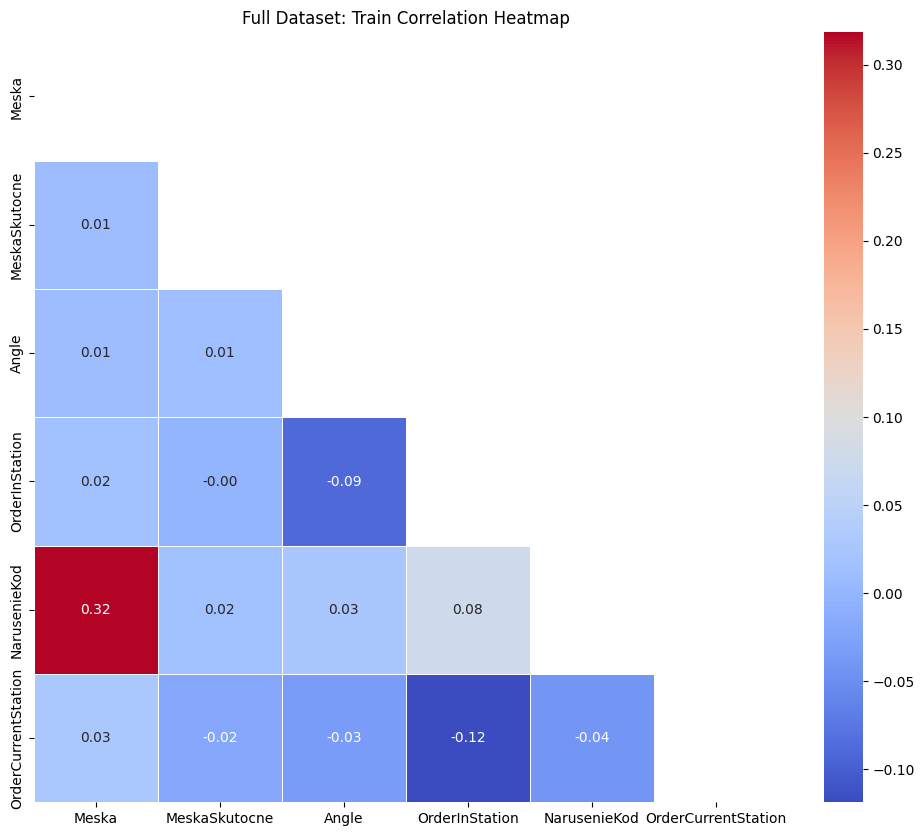

In [4]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq


parquet_file = pq.ParquetFile("../data/raw/train_data.parquet")
numeric_data_list = []

# Process each row group (batch) to keep memory low
for i in range(parquet_file.num_row_groups):
    # Read the specific batch
    df_chunk = parquet_file.read_row_group(i).to_pandas()
    
    # 1. Parse JSON strings into Python lists/dicts
    if 'trains' in df_chunk.columns:
        df_chunk['trains'] = df_chunk['trains'].apply(
            lambda x: json.loads(x) if isinstance(x, str) else x
        )
        
        # 2. Explode the list so 1 row = 1 train
        df_exploded = df_chunk.explode('trains').reset_index(drop=True)
        
        # 3. Normalize dictionaries into separate columns
        train_details = pd.json_normalize(df_exploded['trains'])
        
        # 4. Extract ONLY numeric columns to save RAM
        chunk_numeric = train_details.select_dtypes(include=[np.number])
        numeric_data_list.append(chunk_numeric)

# Combine all numeric results into one final DataFrame
full_numeric_df = pd.concat(numeric_data_list, axis=0).reset_index(drop=True)

# Generate correlation matrix
corr_matrix = full_numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
# Use a mask to hide the redundant upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",
    linewidths=0.5
)
plt.title("Full Dataset: Train Correlation Heatmap")
plt.show()

Row groups: 45


/tmp/ipykernel_863381/1871066276.py:34: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Cas_dt"] = pd.to_datetime(df["Cas"], dayfirst=True, errors="coerce")


  chunk 1/45 — 129,766 snapshots, 99 station codes seen


/tmp/ipykernel_863381/1871066276.py:34: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Cas_dt"] = pd.to_datetime(df["Cas"], dayfirst=True, errors="coerce")


  chunk 2/45 — 244,539 snapshots, 100 station codes seen


...

  chunk 43/45 — 4,617,411 snapshots, 120 station codes seen


/tmp/ipykernel_863381/1871066276.py:34: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Cas_dt"] = pd.to_datetime(df["Cas"], dayfirst=True, errors="coerce")


  chunk 44/45 — 4,706,296 snapshots, 121 station codes seen


/tmp/ipykernel_863381/1871066276.py:34: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Cas_dt"] = pd.to_datetime(df["Cas"], dayfirst=True, errors="coerce")


  chunk 45/45 — 4,805,532 snapshots, 122 station codes seen

Total snapshots processed: 4,805,532
Unique station codes mapped: 122
Codes with name variants (spelling inconsistencies): 121

=== Top 20 stations by snapshot count ===
    code                      name       lat       lon  n_snapshots
13206800 Bratislava hlavná stanica 48.301900 17.607965       605033
13600200                    Košice 48.873332 20.803770       452252
17915000                    Žilina 49.113770 18.718542       184667
13223300     Zvolen osobná stanica 48.569710 19.149430       159758
13363700           Banská Bystrica 48.734750 19.149210       154798
16040800                   Humenné 48.930150 21.824830       146755
13436100                Nové Zámky 48.085450 18.172670       131944
15750300                    Prešov 48.890620 21.320440       129820
13676200                    Trnava 48.369779 17.578300       129437
13016100                      Kúty 48.606372 17.047530       120244
17255100             

In [ ]:
import requests, zipfile, io

# Download ZSR GTFS
import zipfile
import io
import pandas as pd

# The exact static data endpoint for Bratislava (DPB)
url = "https://www.arcgis.com/sharing/rest/content/items/aba12fd2cbac4843bc7406151bc66106/data"

# Adding headers to bypass the 403 Forbidden error
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

r = requests.get(url, headers=headers)
r.raise_for_status()  # Check if the download was successful

z = zipfile.ZipFile(io.BytesIO(r.content))
stops = pd.read_csv(z.open("stops.txt"), dtype=str)

print(stops.head())


print(stops.columns.tolist())
#print(stops.head())
# Look at what stop_id looks like — does it match your codes?

In [ ]:


# Make collection into a DataFrame
import pandas as pd

# limit to 50 000 documents for testing
df = pd.DataFrame(list(collection.find().limit(10000)))
print(f"DataFrame shape: {df.shape}")
print("DataFrame columns:")
print(df.columns)
print("DataFrame sample:")
print(df.head())


In [25]:
# Drop all but the trains collumn
df_trains = df[["trains"]]
print(f"Trains DataFrame shape: {df_trains.shape}")
print("Trains DataFrame sample:")
print(df_trains.head())


Trains DataFrame shape: (10000, 1)
Trains DataFrame sample:
                                              trains
0  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
1  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
2  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
3  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
4  [{'StanicaZCislo': '16040800', 'StanicaDoCislo...


In [26]:
df_trains["trains"]

0       [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
1       [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
2       [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
3       [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
4       [{'StanicaZCislo': '16040800', 'StanicaDoCislo...
                              ...                        
9995    [{'StanicaZCislo': '13600200', 'StanicaDoCislo...
9996    [{'StanicaZCislo': '13600200', 'StanicaDoCislo...
9997    [{'StanicaZCislo': '13600200', 'StanicaDoCislo...
9998    [{'StanicaZCislo': '13600200', 'StanicaDoCislo...
9999    [{'StanicaZCislo': '13600200', 'StanicaDoCislo...
Name: trains, Length: 10000, dtype: object

In [27]:
# Each index in the trains column has 5 snapshots of the train states. We need to explode this column to get one row per snapshot.
df_exploded = df_trains.explode("trains").reset_index(drop=True)
print(f"Exploded DataFrame shape: {df_exploded.shape}")
print("Exploded DataFrame sample:")
print(df_exploded.head())


Exploded DataFrame shape: (1111090, 1)
Exploded DataFrame sample:
                                              trains
0  {'StanicaZCislo': '16040800', 'StanicaDoCislo'...
1  {'StanicaZCislo': '16040800', 'StanicaDoCislo'...
2  {'StanicaZCislo': '13206800', 'StanicaDoCislo'...
3  {'StanicaZCislo': '15750300', 'StanicaDoCislo'...
4  {'StanicaZCislo': '10006500', 'StanicaDoCislo'...


In [ ]:
df_exploded["trains"].apply(lambda x: x.keys())

0         (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
1         (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
2         (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
3         (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
4         (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
                                ...                        
571338    (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
571339    (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
571340    (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
571341    (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
571342    (StanicaZCislo, StanicaDoCislo, Nazov, TypVlak...
Name: trains, Length: 571343, dtype: object

In [28]:
df_exploded = df_exploded["trains"]

In [29]:
df_exploded.head()

0    {'StanicaZCislo': '16040800', 'StanicaDoCislo'...
1    {'StanicaZCislo': '16040800', 'StanicaDoCislo'...
2    {'StanicaZCislo': '13206800', 'StanicaDoCislo'...
3    {'StanicaZCislo': '15750300', 'StanicaDoCislo'...
4    {'StanicaZCislo': '10006500', 'StanicaDoCislo'...
Name: trains, dtype: object

In [30]:
df_exploded.columns

AttributeError: 'Series' object has no attribute 'columns'

In [31]:
len(df_exploded)

1111090

In [32]:
df_exploded[0]

{'StanicaZCislo': '16040800',
 'StanicaDoCislo': '10085900',
 'Nazov': 'EN 442 SLOVAKIA Humenné -> Praha jih',
 'TypVlaku': 'EN',
 'CisloVlaku': '442',
 'NazovVlaku': 'SLOVAKIA',
 'Popis': '(17.02.2026 19:31) Humenné -> Čadca št. hr. (18.02.2026 02:06)',
 'Meska': 2,
 'MeskaSkutocne': 0,
 'MeskaSkutocneZoStanice': None,
 'MeskaColor': 'green',
 'MeskaText': 'V stanici Žilina meškal 2 minúty',
 'MeskaTextEn': 'At station Žilina was 2 min late',
 'MeskaTextColor': '#ff0000',
 'InfoZoStanice': 'Žilina',
 'Cas': datetime.datetime(2026, 2, 18, 1, 21),
 'CasPlan': datetime.datetime(2026, 2, 18, 1, 19),
 'Dopravca': 'Železničná spoločnosť Slovensko, a.s.',
 'Poznamka': '',
 'PoznamkaLangKey': '',
 'NadOd': None,
 'NadDo': None,
 'BNadOd': None,
 'BNadDo': None,
 'Position': [49.2271, 18.74604],
 'PositionNext': None,
 'Angle': -62,
 'OrderInStation': 0,
 'Narusenie': False,
 'NarusenieKod': 0,
 'PotvrdenyOdj': False,
 'NextStation': '19018100',
 'OrderCurrentStation': 103}

In [33]:
df = pd.DataFrame(df_exploded.tolist())
print(f"Final DataFrame shape: {df.shape}")
print("Final DataFrame columns:")
print(df.columns)
print("Final DataFrame sample:")
print(df.head())

Final DataFrame shape: (1111090, 33)
Final DataFrame columns:
Index(['StanicaZCislo', 'StanicaDoCislo', 'Nazov', 'TypVlaku', 'CisloVlaku',
       'NazovVlaku', 'Popis', 'Meska', 'MeskaSkutocne',
       'MeskaSkutocneZoStanice', 'MeskaColor', 'MeskaText', 'MeskaTextEn',
       'MeskaTextColor', 'InfoZoStanice', 'Cas', 'CasPlan', 'Dopravca',
       'Poznamka', 'PoznamkaLangKey', 'NadOd', 'NadDo', 'BNadOd', 'BNadDo',
       'Position', 'PositionNext', 'Angle', 'OrderInStation', 'Narusenie',
       'NarusenieKod', 'PotvrdenyOdj', 'NextStation', 'OrderCurrentStation'],
      dtype='str')
Final DataFrame sample:
  StanicaZCislo StanicaDoCislo  \
0      16040800       10085900   
1      16040800       13206800   
2      13206800       16040800   
3      15750300       10085900   
4      10006500       13206800   

                                             Nazov TypVlaku CisloVlaku  \
0             EN 442 SLOVAKIA Humenné -> Praha jih       EN        442   
1                                

In [34]:
len(df)

1111090

In [35]:
df.head()

,StanicaZCislo,StanicaDoCislo,Nazov,TypVlaku,CisloVlaku,NazovVlaku,Popis,Meska,MeskaSkutocne,MeskaSkutocneZoStanice,...,BNadDo,Position,PositionNext,Angle,OrderInStation,Narusenie,NarusenieKod,PotvrdenyOdj,NextStation,OrderCurrentStation
0,16040800,10085900,EN 442 SLOVAKIA Humenné -> Praha jih,EN,442,SLOVAKIA,(17.02.2026 19:31) Humenné -> Čadca št. hr. (1...,2,0,NaN,...,NaN,"[49.2271, 18.74604]",None,-62,0,False,0,False,19018100,103
1,16040800,13206800,R 680 ZEMPLÍN,R,680,ZEMPLÍN,(17.02.2026 21:51) Humenné -> Bratislava hlavn...,1,0,NaN,...,NaN,"[49.08355, 20.06547]",None,-102,0,False,0,True,13171400,69
2,13206800,16040800,R 681 ZEMPLÍN,R,681,ZEMPLÍN,(17.02.2026 22:55) Bratislava hlavná stanica -...,3,0,NaN,...,NaN,"[49.2271, 18.74604]",None,103,1,False,0,False,19008200,73
3,15750300,10085900,EC 1252 LEO EXPRESS Prešov -> Praha hl.n.,EC,1252,LEO EXPRESS,(17.02.2026 21:56) Prešov -> Čadca št. hr. (18...,6,0,NaN,...,NaN,"[49.233573, 18.734264]",None,30,0,False,0,True,18245100,82
4,10006500,13206800,REX 2540 Wien Hbf -> Bratislava hlavná stanica,REX,2540,,(18.02.2026 01:26) Devínska Nová Ves št. hr. -...,0,0,NaN,...,NaN,"[48.24134, 16.94675]",None,125,0,False,0,False,13136700,0


In [ ]:
# Drop multiple columns by name
df = df.drop(columns=['Angle', 'MeskaSkutocne', 'MeskaSkutocneZoStanice', 'BNadDo'])


In [ ]:
df = df.drop(columns=['MeskaColor', 'MeskaText', 'NadOd', 'NadDo', 'BNadOd'])
df.columns

Index(['StanicaZCislo', 'StanicaDoCislo', 'Nazov', 'TypVlaku', 'CisloVlaku',
       'NazovVlaku', 'Popis', 'Meska', 'MeskaTextEn', 'MeskaTextColor',
       'InfoZoStanice', 'Cas', 'CasPlan', 'Dopravca', 'Poznamka',
       'PoznamkaLangKey', 'Position', 'PositionNext', 'OrderInStation',
       'Narusenie', 'NarusenieKod', 'PotvrdenyOdj', 'NextStation',
       'OrderCurrentStation'],
      dtype='str')

In [ ]:
df = df.drop(columns=['MeskaTextEn', 'MeskaTextColor', 'Poznamka', 'PoznamkaLangKey'])
df.head()

,StanicaZCislo,StanicaDoCislo,Nazov,TypVlaku,CisloVlaku,NazovVlaku,Popis,Meska,InfoZoStanice,Cas,CasPlan,Dopravca,Position,PositionNext,OrderInStation,Narusenie,NarusenieKod,PotvrdenyOdj,NextStation,OrderCurrentStation
0,16040800,10085900,EN 442 SLOVAKIA Humenné -> Praha jih,EN,442,SLOVAKIA,(17.02.2026 19:31) Humenné -> Čadca št. hr. (1...,2,Žilina,2026-02-18 01:21:00,2026-02-18 01:19:00,"Železničná spoločnosť Slovensko, a.s.","[49.2271, 18.74604]",None,0,False,0,False,19018100,103
1,16040800,13206800,R 680 ZEMPLÍN,R,680,ZEMPLÍN,(17.02.2026 21:51) Humenné -> Bratislava hlavn...,1,Štrba,2026-02-18 01:23:00,2026-02-18 01:22:00,"Železničná spoločnosť Slovensko, a.s.","[49.08355, 20.06547]",None,0,False,0,True,13171400,69
2,13206800,16040800,R 681 ZEMPLÍN,R,681,ZEMPLÍN,(17.02.2026 22:55) Bratislava hlavná stanica -...,3,Žilina,2026-02-18 01:27:00,2026-02-18 01:24:00,"Železničná spoločnosť Slovensko, a.s.","[49.2271, 18.74604]",None,1,False,0,False,19008200,73
3,15750300,10085900,EC 1252 LEO EXPRESS Prešov -> Praha hl.n.,EC,1252,LEO EXPRESS,(17.02.2026 21:56) Prešov -> Čadca št. hr. (18...,6,Budatín odb.,2026-02-18 01:25:00,2026-02-18 01:19:00,Leo Express s.r.o.,"[49.233573, 18.734264]",None,0,False,0,True,18245100,82
4,10006500,13206800,REX 2540 Wien Hbf -> Bratislava hlavná stanica,REX,2540,,(18.02.2026 01:26) Devínska Nová Ves št. hr. -...,0,Devínska Nová Ves št. hr.,NaT,2026-02-18 01:26:00,"Železničná spoločnosť Slovensko, a.s.","[48.24134, 16.94675]",None,0,False,0,False,13136700,0


/tmp/ipykernel_646562/964453120.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[4].boxplot(plot_data, labels=type_order, patch_artist=True,


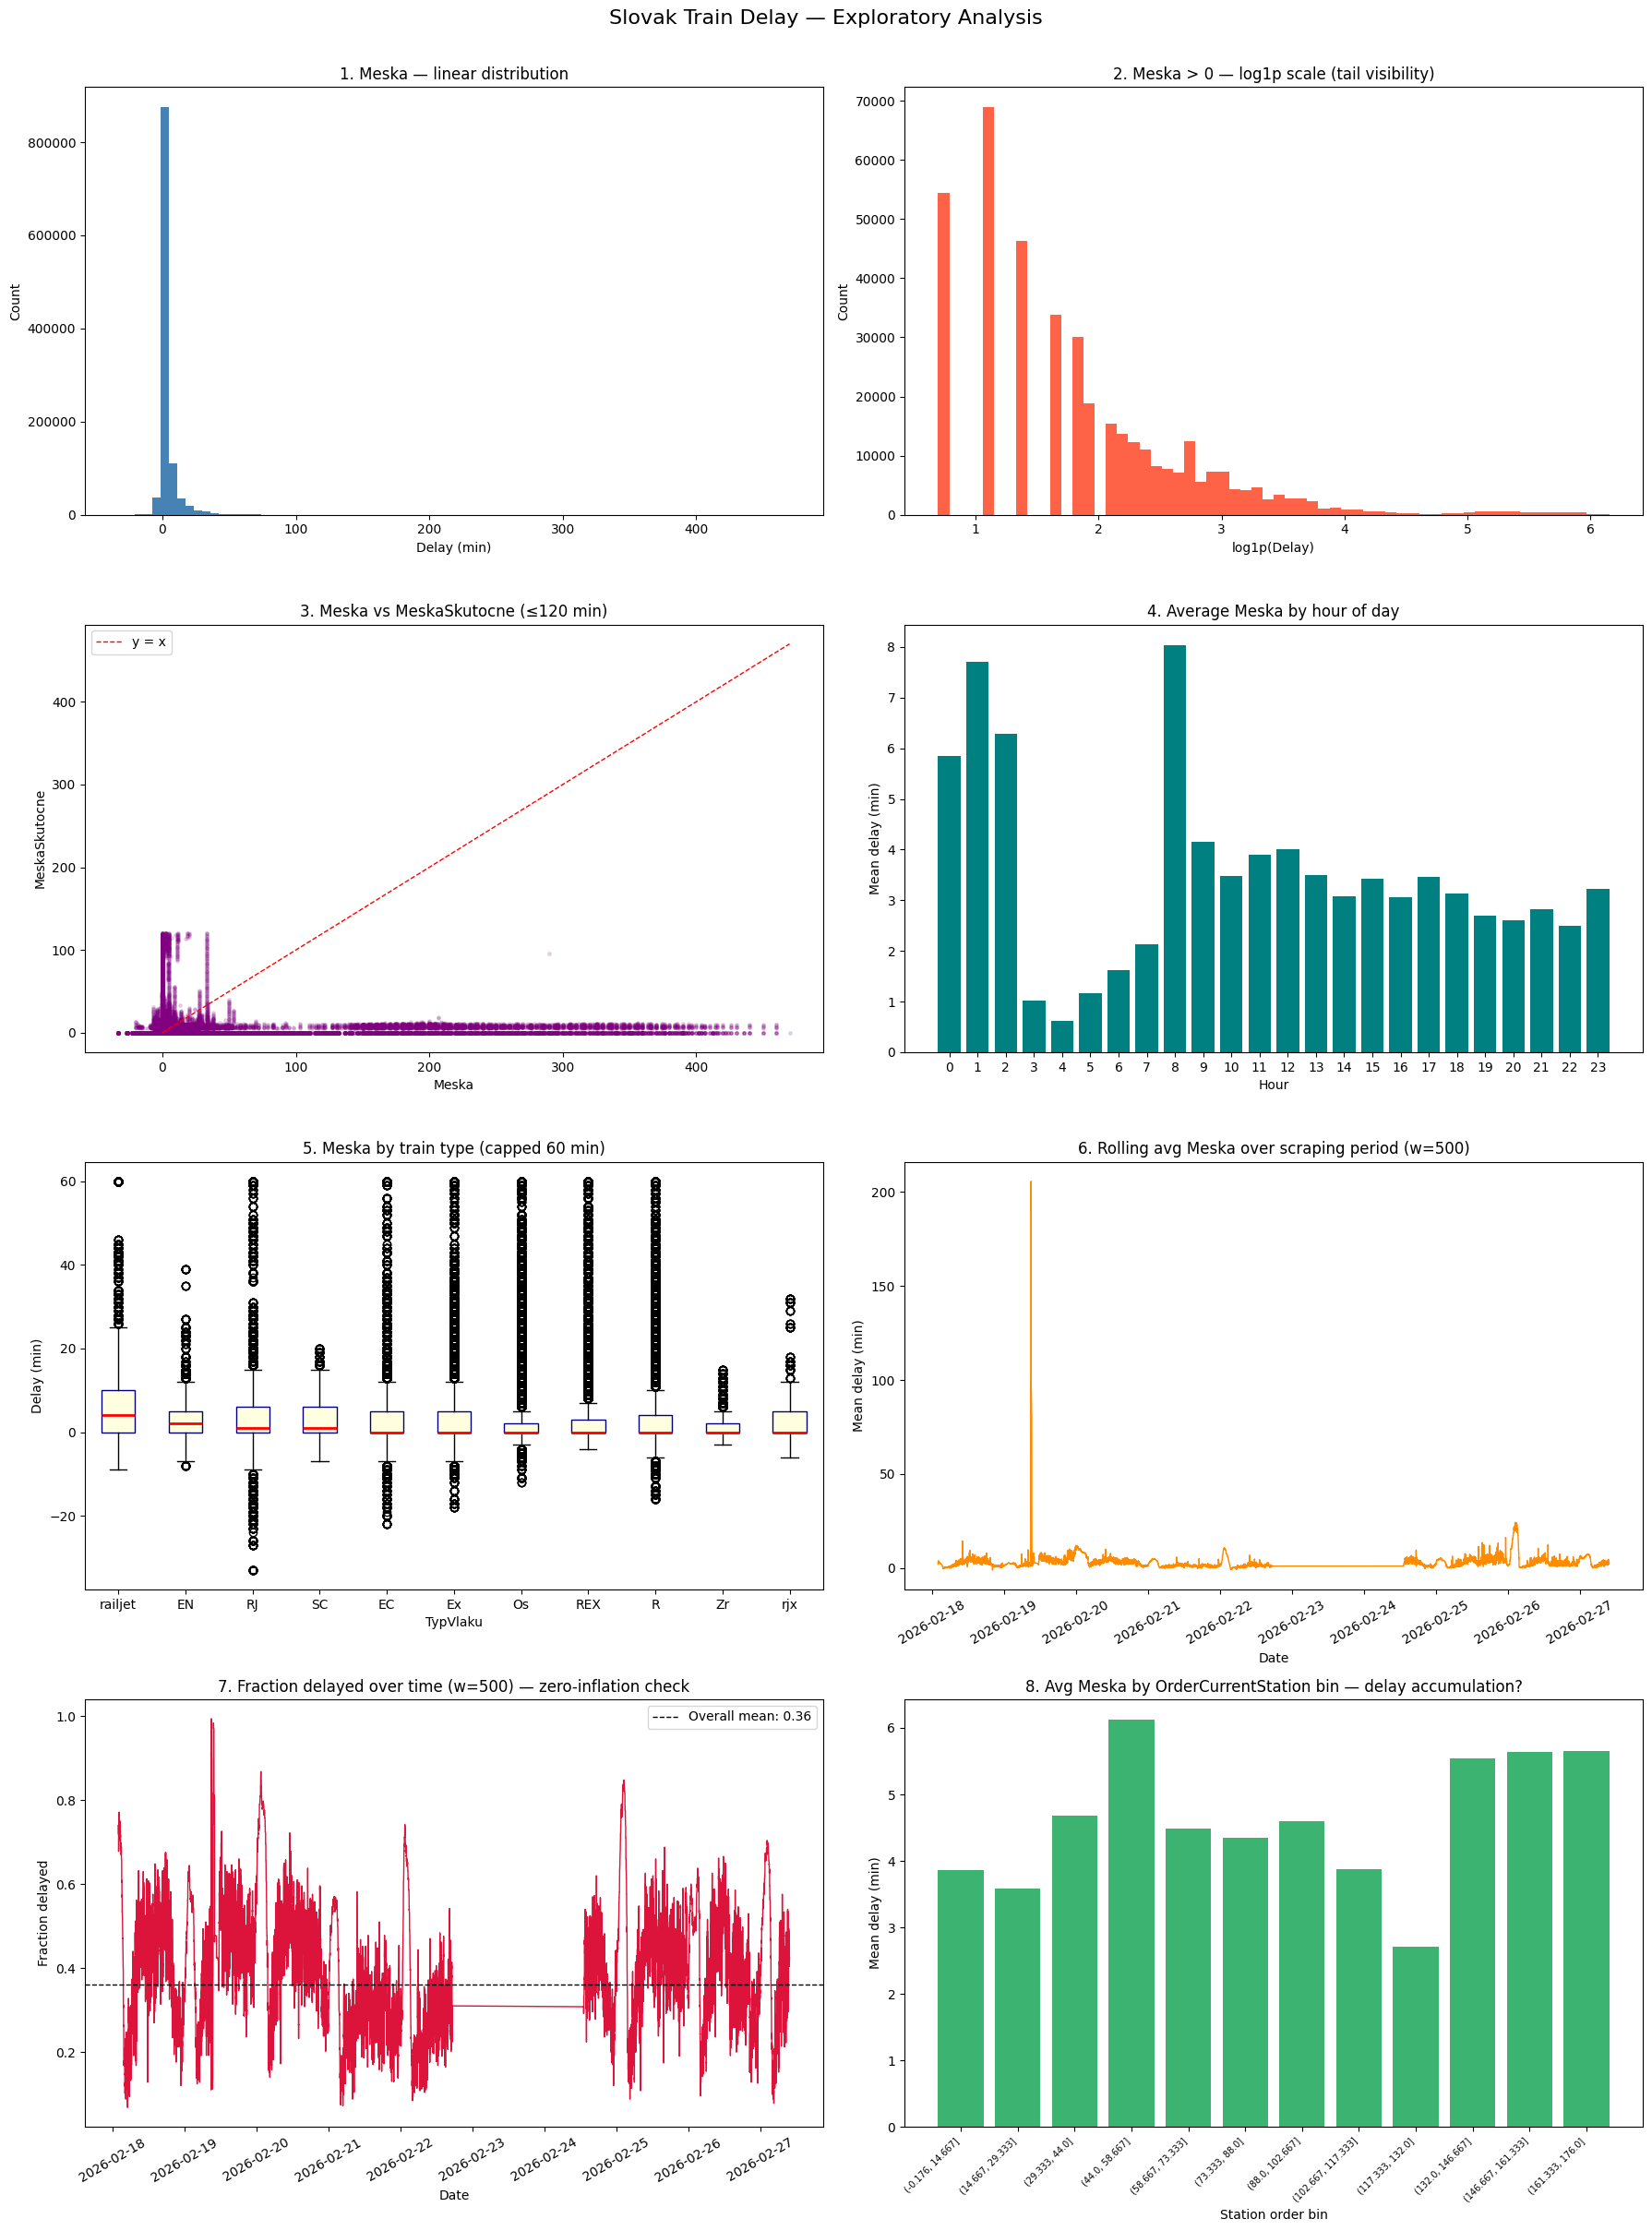

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Temporal prep ────────────────────────────────────────────────────────────
df['Cas_dt'] = pd.to_datetime(df['Cas'], dayfirst=True, errors='coerce')
df['hour'] = df['Cas_dt'].dt.hour
df['is_delayed'] = (df['Meska'] > 0).astype(int)

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

# ── 1. Meska distribution (linear) ───────────────────────────────────────────
axes[0].hist(df['Meska'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('1. Meska — linear distribution')
axes[0].set_xlabel('Delay (min)')
axes[0].set_ylabel('Count')

# ── 2. Meska distribution (log scale, >0 only) ───────────────────────────────
axes[1].hist(df[df['Meska'] > 0]['Meska'].apply(np.log1p), bins=60,
             color='tomato', edgecolor='none')
axes[1].set_title('2. Meska > 0 — log1p scale (tail visibility)')
axes[1].set_xlabel('log1p(Delay)')
axes[1].set_ylabel('Count')

# ── 3. Meska vs MeskaSkutocne scatter ────────────────────────────────────────
mask = ((df['Meska'] != 0) | (df['MeskaSkutocne'] != 0)) & (df['MeskaSkutocne'] <= 120)
axes[2].scatter(df.loc[mask, 'Meska'], df.loc[mask, 'MeskaSkutocne'],
                alpha=0.15, s=6, color='purple')
# y=x reference line
lim = max(df.loc[mask, 'Meska'].max(), df.loc[mask, 'MeskaSkutocne'].max())
axes[2].plot([0, lim], [0, lim], 'r--', linewidth=1, label='y = x')
axes[2].set_title('3. Meska vs MeskaSkutocne (≤120 min)')
axes[2].set_xlabel('Meska')
axes[2].set_ylabel('MeskaSkutocne')
axes[2].legend()

# ── 4. Average delay by hour of day ──────────────────────────────────────────
hourly = df.groupby('hour')['Meska'].mean()
axes[3].bar(hourly.index, hourly.values, color='teal', edgecolor='none')
axes[3].set_title('4. Average Meska by hour of day')
axes[3].set_xlabel('Hour')
axes[3].set_ylabel('Mean delay (min)')
axes[3].set_xticks(range(0, 24))

# ── 5. Delay by TypVlaku (box, capped at 60 min for readability) ─────────────
type_order = (df.groupby('TypVlaku')['Meska']
                .median()
                .sort_values(ascending=False)
                .index.tolist())
plot_data = [df.loc[df['TypVlaku'] == t, 'Meska'].clip(upper=60).values
             for t in type_order]
axes[4].boxplot(plot_data, labels=type_order, patch_artist=True,
                boxprops=dict(facecolor='lightyellow', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[4].set_title('5. Meska by train type (capped 60 min)')
axes[4].set_xlabel('TypVlaku')
axes[4].set_ylabel('Delay (min)')

# ── 6. Rolling average delay over scraping period ────────────────────────────
df_sorted = df.dropna(subset=['Cas_dt']).sort_values('Cas_dt')
rolling_mean = df_sorted['Meska'].rolling(window=500, min_periods=50).mean()
axes[5].plot(df_sorted['Cas_dt'], rolling_mean, color='darkorange', linewidth=1)
axes[5].set_title('6. Rolling avg Meska over scraping period (w=500)')
axes[5].set_xlabel('Date')
axes[5].set_ylabel('Mean delay (min)')
axes[5].tick_params(axis='x', rotation=30)

# ── 7. Fraction delayed over scraping period (zero-inflation drift) ───────────
rolling_frac = df_sorted['is_delayed'].rolling(window=500, min_periods=50).mean()
axes[6].plot(df_sorted['Cas_dt'], rolling_frac, color='crimson', linewidth=1)
axes[6].axhline(df['is_delayed'].mean(), color='black', linestyle='--',
                linewidth=1, label=f"Overall mean: {df['is_delayed'].mean():.2f}")
axes[6].set_title('7. Fraction delayed over time (w=500) — zero-inflation check')
axes[6].set_xlabel('Date')
axes[6].set_ylabel('Fraction delayed')
axes[6].tick_params(axis='x', rotation=30)
axes[6].legend()

# ── 8. Average delay by route progress (OrderCurrentStation bins) ─────────────
df_prog = df.dropna(subset=['OrderCurrentStation'])
df_prog = df_prog[df_prog['OrderCurrentStation'] >= 0]
df_prog['progress_bin'] = pd.cut(df_prog['OrderCurrentStation'], bins=12)
prog_mean = df_prog.groupby('progress_bin', observed=True)['Meska'].mean()
axes[7].bar(range(len(prog_mean)), prog_mean.values, color='mediumseagreen', edgecolor='none')
axes[7].set_xticks(range(len(prog_mean)))
axes[7].set_xticklabels([str(b) for b in prog_mean.index], rotation=45, ha='right', fontsize=7)
axes[7].set_title('8. Avg Meska by OrderCurrentStation bin — delay accumulation?')
axes[7].set_xlabel('Station order bin')
axes[7].set_ylabel('Mean delay (min)')

plt.suptitle('Slovak Train Delay — Exploratory Analysis', fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

/home/admin/git/slovak-train-delay-prediction/analysis/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.draw()
/tmp/ipykernel_646562/1110219041.py:125: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/admin/git/slovak-train-delay-prediction/analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


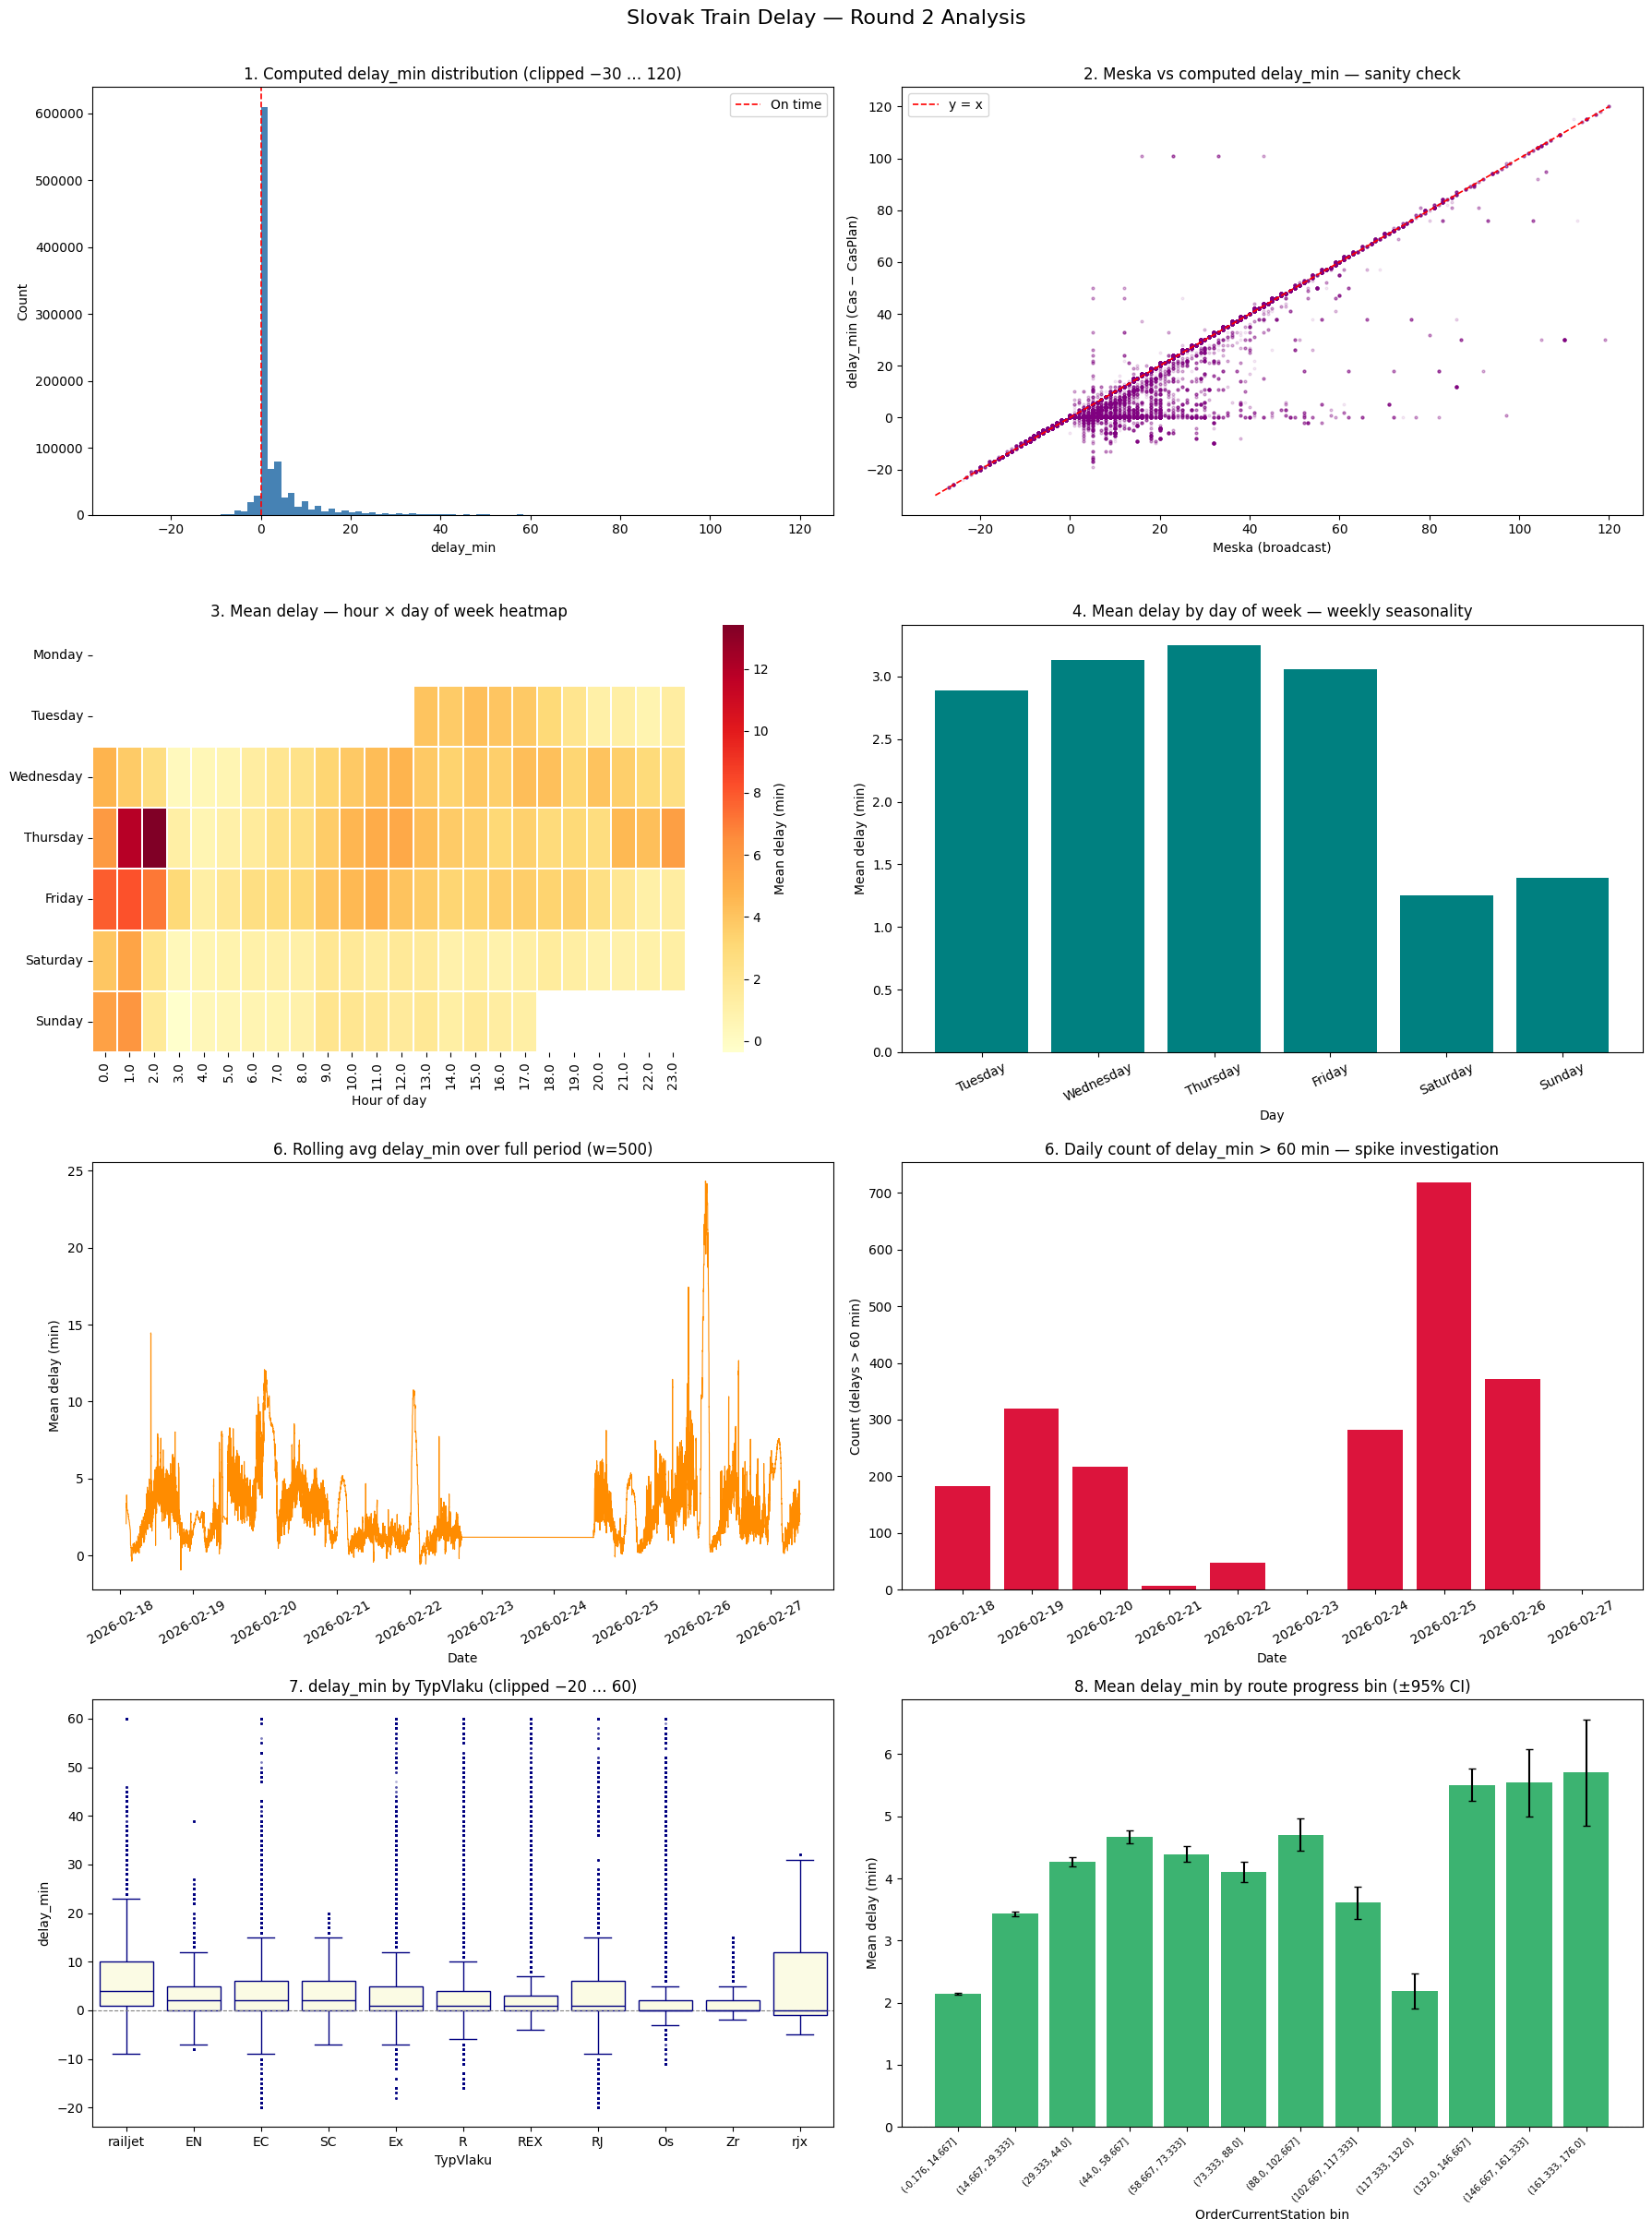

=== Meska vs computed delay discrepancy ===
count    988582.000
mean         -0.417
std          10.227
min        -470.000
25%           0.000
50%           0.000
75%           0.000
max          85.000
dtype: float64

Rows where |diff| > 2 min : 1.2%
Rows where |diff| > 5 min : 0.8%

delay_min range  : -33.0 … 129.0
Negative delay rows : 5.7%


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Compute ground-truth delay ────────────────────────────────────────────────
df['Cas_dt']     = pd.to_datetime(df['Cas'],     dayfirst=True, errors='coerce')
df['CasPlan_dt'] = pd.to_datetime(df['CasPlan'], dayfirst=True, errors='coerce')
df['delay_min']  = (df['Cas_dt'] - df['CasPlan_dt']).dt.total_seconds() / 60.0

# ── Temporal features ─────────────────────────────────────────────────────────
df['hour']       = df['Cas_dt'].dt.hour
df['dow']        = df['Cas_dt'].dt.dayofweek          # 0=Mon … 6=Sun
df['dow_name']   = df['Cas_dt'].dt.day_name()
df['date']       = df['Cas_dt'].dt.normalize()
df['is_delayed'] = (df['delay_min'] > 0).astype(int)

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

# ── 1. Computed delay distribution (full, symmetric — shows negative side) ────
clipped = df['delay_min'].clip(-30, 120)
axes[0].hist(clipped, bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linewidth=1.2, linestyle='--', label='On time')
axes[0].set_title('1. Computed delay_min distribution (clipped −30 … 120)')
axes[0].set_xlabel('delay_min')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── 2. Meska vs computed delay — sanity check before dropping Meska ───────────
mask = df['delay_min'].between(-30, 120) & df['Meska'].between(-30, 120)
axes[1].scatter(df.loc[mask, 'Meska'], df.loc[mask, 'delay_min'],
                alpha=0.08, s=4, color='purple')
lim = 120
axes[1].plot([-30, lim], [-30, lim], 'r--', linewidth=1.2, label='y = x')
axes[1].set_title('2. Meska vs computed delay_min — sanity check')
axes[1].set_xlabel('Meska (broadcast)')
axes[1].set_ylabel('delay_min (Cas − CasPlan)')
axes[1].legend()

# ── 3. Heatmap: mean delay by hour × day of week ─────────────────────────────
pivot = (df.groupby(['dow_name', 'hour'])['delay_min']
           .mean()
           .unstack(level='hour')
           .reindex(DOW_ORDER))
sns.heatmap(pivot, ax=axes[2], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Mean delay (min)'})
axes[2].set_title('3. Mean delay — hour × day of week heatmap')
axes[2].set_xlabel('Hour of day')
axes[2].set_ylabel('')

# ── 4. Average delay by day of week ──────────────────────────────────────────
dow_mean = (df.groupby('dow_name')['delay_min']
              .mean()
              .reindex(DOW_ORDER))
axes[3].bar(DOW_ORDER, dow_mean.values, color='teal', edgecolor='none')
axes[3].set_title('4. Mean delay by day of week — weekly seasonality')
axes[3].set_xlabel('Day')
axes[3].set_ylabel('Mean delay (min)')
axes[3].tick_params(axis='x', rotation=25)

# ── 5. Rolling avg delay over full scraping period ───────────────────────────
df_sorted = df.dropna(subset=['Cas_dt']).sort_values('Cas_dt')
roll_mean = df_sorted['delay_min'].rolling(window=500, min_periods=50).mean()
axes[4].plot(df_sorted['Cas_dt'], roll_mean, color='darkorange', linewidth=0.8)
axes[4].set_title('6. Rolling avg delay_min over full period (w=500)')
axes[4].set_xlabel('Date')
axes[4].set_ylabel('Mean delay (min)')
axes[4].tick_params(axis='x', rotation=30)

# ── 6. Daily outlier count — spikes like Feb 19 ──────────────────────────────
daily_outliers = (df.groupby('date')
                    .apply(lambda x: (x['delay_min'] > 60).sum())
                    .reset_index(name='outlier_count'))
axes[5].bar(daily_outliers['date'], daily_outliers['outlier_count'],
            color='crimson', edgecolor='none', width=0.8)
axes[5].set_title('6. Daily count of delay_min > 60 min — spike investigation')
axes[5].set_xlabel('Date')
axes[5].set_ylabel('Count (delays > 60 min)')
axes[5].tick_params(axis='x', rotation=30)

# ── 7. Delay by TypVlaku (computed delay, capped 60 min) ─────────────────────
# ── 7. Delay by TypVlaku (computed delay, capped 60 min) ─────────────────────
type_order = (df.groupby('TypVlaku')['delay_min']
                .median()
                .sort_values(ascending=False)
                .index.tolist())

# Create a temporary clipped column/series for plotting
clipped_delay = df['delay_min'].clip(-20, 60)

sns.boxplot(
    data=df, 
    x='TypVlaku', 
    y=clipped_delay, 
    order=type_order, 
    ax=axes[6],
    color='lightyellow',
    linecolor='navy', # Note: kwargs can vary slightly by seaborn version
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)

axes[6].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[6].set_title('7. delay_min by TypVlaku (clipped −20 … 60)')

# ── 8. Route progress vs delay (computed) ────────────────────────────────────
df_prog = df.dropna(subset=['OrderCurrentStation', 'delay_min'])
df_prog = df_prog[df_prog['OrderCurrentStation'] >= 0]
df_prog['progress_bin'] = pd.cut(df_prog['OrderCurrentStation'], bins=12)
prog_stats = df_prog.groupby('progress_bin', observed=True)['delay_min'].agg(['mean', 'sem'])
axes[7].bar(range(len(prog_stats)), prog_stats['mean'],
            yerr=prog_stats['sem'] * 1.96,
            color='mediumseagreen', edgecolor='none', capsize=3)
axes[7].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[7].set_xticks(range(len(prog_stats)))
axes[7].set_xticklabels([str(b) for b in prog_stats.index],
                         rotation=45, ha='right', fontsize=7)
axes[7].set_title('8. Mean delay_min by route progress bin (±95% CI)')
axes[7].set_xlabel('OrderCurrentStation bin')
axes[7].set_ylabel('Mean delay (min)')

plt.suptitle('Slovak Train Delay — Round 2 Analysis', fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

# ── Quick console sanity check ────────────────────────────────────────────────
diff = df['delay_min'] - df['Meska']
print("=== Meska vs computed delay discrepancy ===")
print(diff.describe().round(3))
print(f"\nRows where |diff| > 2 min : {(diff.abs() > 2).mean():.1%}")
print(f"Rows where |diff| > 5 min : {(diff.abs() > 5).mean():.1%}")
print(f"\ndelay_min range  : {df['delay_min'].min():.1f} … {df['delay_min'].max():.1f}")
print(f"Negative delay rows : {(df['delay_min'] < 0).mean():.1%}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:

plt.figure(figsize=(12, 8))


In [ ]:

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

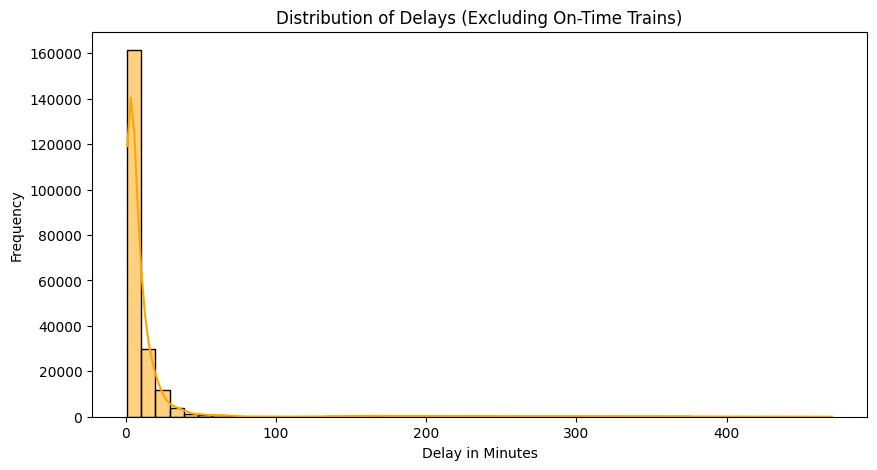

In [ ]:
plt.figure(figsize=(10, 5))
# Filtering for delays > 0 to see the distribution of actual delays
sns.histplot(df[df['Meska'] > 0]['Meska'], bins=50, kde=True, color='orange')
plt.title("Distribution of Delays (Excluding On-Time Trains)")
plt.xlabel("Delay in Minutes")
plt.ylabel("Frequency")
plt.show()

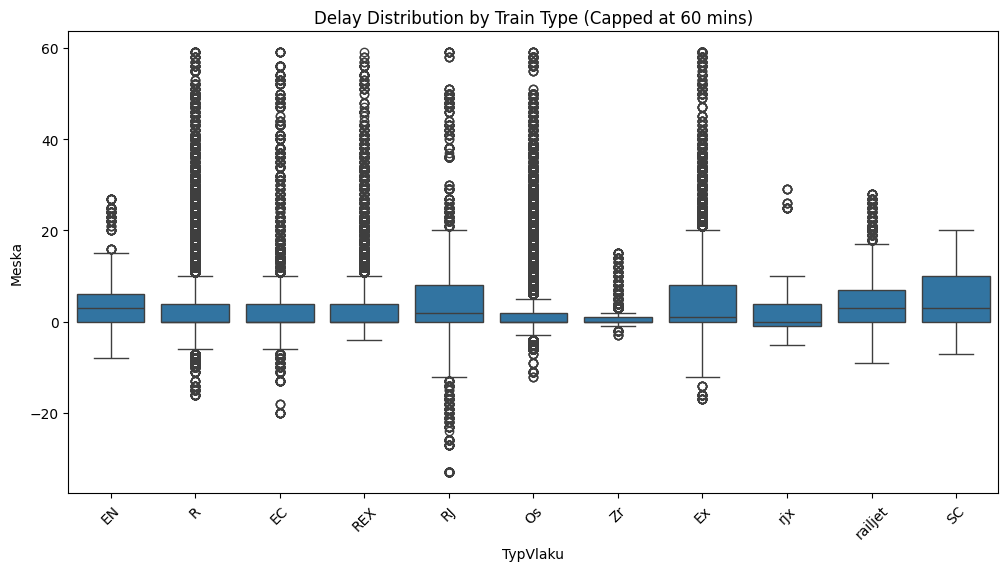

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='TypVlaku', y='Meska', data=df[df['Meska'] < 60]) # Capped at 60m for visibility
plt.title("Delay Distribution by Train Type (Capped at 60 mins)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Check unique values for categorical columns
cat_cols = ['TypVlaku', 'StanicaZCislo', 'StanicaDoCislo', 'NarusenieKod']
for col in cat_cols:
    print(f"{col} has {df[col].nunique()} unique values")

TypVlaku has 11 unique values
StanicaZCislo has 106 unique values
StanicaDoCislo has 107 unique values
NarusenieKod has 3 unique values


In [ ]:
df.head()

,StanicaZCislo,StanicaDoCislo,Nazov,TypVlaku,CisloVlaku,NazovVlaku,Popis,Meska,MeskaTextEn,MeskaTextColor,...,NarusenieKod,PotvrdenyOdj,NextStation,OrderCurrentStation,DayOfWeek,HourOfDay,Lat,Lon,Station_Betweenness,Station_Inflow_Count
0,16040800,10085900,EN 442 SLOVAKIA Humenné -> Praha jih,EN,442,SLOVAKIA,(17.02.2026 19:31) Humenné -> Čadca št. hr. (1...,2.0,At station Žilina was 2 min late,#ff0000,...,0,False,19018100,103,2.0,1.0,49.227100,18.746040,0.048683,6
1,16040800,13206800,R 680 ZEMPLÍN,R,680,ZEMPLÍN,(17.02.2026 21:51) Humenné -> Bratislava hlavn...,1.0,At station Štrba was 1 min late,#ff0000,...,0,True,13171400,69,2.0,1.0,49.083550,20.065470,0.048683,6
2,13206800,16040800,R 681 ZEMPLÍN,R,681,ZEMPLÍN,(17.02.2026 22:55) Bratislava hlavná stanica -...,3.0,At station Žilina was 3 min late,#ff0000,...,0,False,19008200,73,2.0,1.0,49.227100,18.746040,0.354512,19
3,15750300,10085900,EC 1252 LEO EXPRESS Prešov -> Praha hl.n.,EC,1252,LEO EXPRESS,(17.02.2026 21:56) Prešov -> Čadca št. hr. (18...,6.0,At station Budatín odb. was 6 min late,#ff0000,...,0,True,18245100,82,2.0,1.0,49.233573,18.734264,0.063424,8
4,10006500,13206800,REX 2540 Wien Hbf -> Bratislava hlavná stanica,REX,2540,,(18.02.2026 01:26) Devínska Nová Ves št. hr. -...,NaN,Train waiting to depart,#006AA0,...,0,False,13136700,0,NaN,NaN,48.241340,16.946750,0.000000,1


In [ ]:
df['Cas'] = pd.to_datetime(df['Cas'], errors='coerce')
df['CasPlan'] = pd.to_datetime(df['CasPlan'], errors='coerce')
df['Meska'] = df['Cas'] - df['CasPlan']

In [ ]:
df['Meska'] = df['Meska'].dt.total_seconds() / 60  # Convert to minutes

In [ ]:
df['DayOfWeek'] = df['Cas'].dt.dayofweek
df['HourOfDay'] = df['Cas'].dt.hour

In [ ]:
df['TypVlaku'] = df['TypVlaku'].astype('category')

In [ ]:
# Assuming 'Position' is a string representation of a list
import ast

def split_gps(pos):
    try:
        if isinstance(pos, str):
            pos = ast.literal_eval(pos)
        return pd.Series([pos[0], pos[1]])
    except:
        return pd.Series([None, None])

df[['Lat', 'Lon']] = df['Position'].apply(split_gps)

In [ ]:
df.columns

Index(['StanicaZCislo', 'StanicaDoCislo', 'Nazov', 'TypVlaku', 'CisloVlaku',
       'NazovVlaku', 'Popis', 'Meska', 'MeskaTextEn', 'MeskaTextColor',
       'InfoZoStanice', 'Cas', 'CasPlan', 'Dopravca', 'Poznamka',
       'PoznamkaLangKey', 'Position', 'PositionNext', 'OrderInStation',
       'Narusenie', 'NarusenieKod', 'PotvrdenyOdj', 'NextStation',
       'OrderCurrentStation', 'DayOfWeek', 'HourOfDay', 'Lat', 'Lon'],
      dtype='str')

In [ ]:
df = df.drop(columns=['Position'])

In [ ]:
import networkx as nx
from geopy.distance import geodesic

# 1. Create unique routes with average distance/delay
# We aggregate by the 'Segment' (From -> To)
edges_df = df.groupby(['StanicaZCislo', 'StanicaDoCislo']).agg({
    'Meska': 'mean',
    'Lat': 'first',
    'Lon': 'first'
}).reset_index()

G = nx.DiGraph()

# 2. Add edges and calculate Haversine distance for 'Length'
for _, row in edges_df.iterrows():
    # Note: You'd ideally need the Lat/Lon of both Start and End station
    # Assuming you have a mapping of StationID -> (Lat, Lon)
    G.add_edge(row['StanicaZCislo'], row['StanicaDoCislo'], 
               avg_delay=row['Meska'])

In [ ]:
# Calculate Centrality
betweenness = nx.betweenness_centrality(G)
in_degree = dict(G.in_degree()) # "Current Inflow" capacity

# Map these back to your main dataframe
df['Station_Betweenness'] = df['StanicaZCislo'].map(betweenness)
df['Station_Inflow_Count'] = df['StanicaZCislo'].map(in_degree)


In [ ]:
from pyvis.network import Network

# Change cdn_resources to 'in_line' or 'remote'
net = Network(
    height="750px", 
    width="100%", 
    bgcolor="#222222", 
    font_color="white", 
    notebook=True, 
    cdn_resources='in_line'  # This embeds the JS directly in the HTML
)

net.from_nx(G)
net.toggle_physics(True)

# Save and display
net.show("../outputs/maps/train_network.html")


train_network.html
